First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

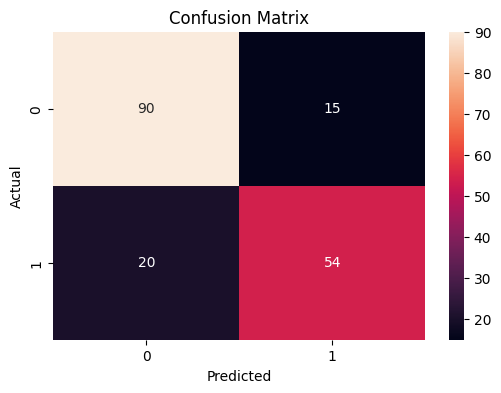

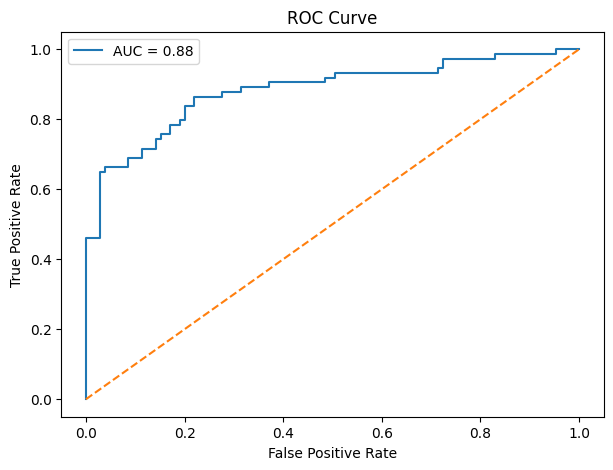

In [3]:
# ============================================
# Week 4 Task: ML Model Development
# Dataset: Titanic train.csv
# Algorithm: Logistic Regression
# ============================================
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
# ============================================
# 1. Load Dataset
# ============================================
df = pd.read_csv("train.csv")
print("First 5 Rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())
# ============================================
# 2. Data Cleaning
# ============================================
# Remove unnecessary columns
df = df.drop(
    ["PassengerId", "Name", "Ticket", "Cabin"],
    axis=1
)
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)
# Fill Embarked missing values
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)
# ============================================
# 3. Convert Categorical Data
# ============================================
# Convert Sex
df["Sex"] = LabelEncoder().fit_transform(
    df["Sex"]
)
# Convert Embarked
df["Embarked"] = LabelEncoder().fit_transform(
    df["Embarked"]
)
# ============================================
#4. Split Features and Target
# ============================================
X = df.drop(
    "Survived",
    axis=1
)
y = df["Survived"]
# ============================================
# 5. Train Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# ============================================
# 6. Feature Scaling
# ============================================
scaler = StandardScaler()
X_train = scaler.fit_transform(
    X_train
)
X_test = scaler.transform(
    X_test
)
# ============================================
# 7. Model Training
# ===========================================
model = LogisticRegression()
model.fit(
    X_train,
    y_train
)
# ============================================
# 8. Prediction
# ============================================
y_pred = model.predict(
    X_test
)
# ============================================
# 9. Evaluation
# ============================================
print("\nModel Performance")
print("--------------------")
print(
    "Accuracy:",
    accuracy_score(y_test,y_pred)
)
print(
    "Precision:",
    precision_score(y_test,y_pred)
)
print(
    "Recall:",
    recall_score(y_test,y_pred)
)
print(
    "F1 Score:",
    f1_score(y_test,y_pred)
)
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred
    )
)
# ============================================
# 10. Visualization 1
# Confusion Matrix
# ============================================
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()
# ============================================
# 11. Visualization 2
# ROC Curve
# ============================================
y_probability = model.predict_proba(
    X_test
)[:,1]
fpr, tpr, threshold = roc_curve(
    y_test,
    y_probability
)
roc_auc = auc(
    fpr,
    tpr
)
plt.figure(figsize=(7,5))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)
plt.xlabel(
    "False Positive Rate"
)
plt.ylabel(
    "True Positive Rate"
)
plt.title(
    "ROC Curve"
)

plt.legend()
plt.show()